In [2]:
import os
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = r"D:\D drive\Labmentix\Task 4\Tourism_Analytics\data"

transaction = pd.read_excel(DATA_DIR + r"\Transaction.xlsx")
user = pd.read_excel(DATA_DIR + r"\User.xlsx")
city = pd.read_excel(DATA_DIR + r"\City.xlsx")
country = pd.read_excel(DATA_DIR + r"\Country.xlsx")
region = pd.read_excel(DATA_DIR + r"\Region.xlsx")
continent = pd.read_excel(DATA_DIR + r"\Continent.xlsx")
item = pd.read_excel(DATA_DIR + r"\Additional_Data_for_Attraction_Sites\Updated_Item.xlsx")
type_df = pd.read_excel(DATA_DIR + r"\Type.xlsx")
mode = pd.read_excel(DATA_DIR + r"\Mode.xlsx")

print("Transaction:", transaction.shape)
print("User:", user.shape)
print("Updated_Item:", item.shape)

Transaction: (52930, 7)
User: (33530, 5)
Updated_Item: (1698, 5)


In [4]:
type_df = pd.read_excel(DATA_DIR + r"\Type.xlsx")
mode = pd.read_excel(DATA_DIR + r"\Mode.xlsx")

# Transaction ka VisitMode column actually ek ID hai (naam nahi), rename taaki confusion na ho
transaction = transaction.rename(columns={'VisitMode': 'VisitModeId'})

# Tables ko step-by-step merge karo
df = transaction.merge(user, on='UserId', how='left')
df = df.merge(mode, on='VisitModeId', how='left')
df = df.merge(item, on='AttractionId', how='left')
df = df.merge(type_df, on='AttractionTypeId', how='left')
df = df.merge(continent, on='ContinentId', how='left')
df = df.merge(region, on='RegionId', how='left', suffixes=('', '_region'))
df = df.merge(country, on='CountryId', how='left', suffixes=('', '_country'))
df = df.merge(city, on='CityId', how='left', suffixes=('', '_city'))

df = df.drop(columns=['ContinentId_region', 'RegionId_country', 'CountryId_city'])

print("Final merged shape:", df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

Final merged shape: (52930, 21)
CityId      8
CityName    8
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9056\2425196811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis', ax=axes[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9056\2425196811.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='VisitMode', order=order, palette='rocket', ax=axes[1])


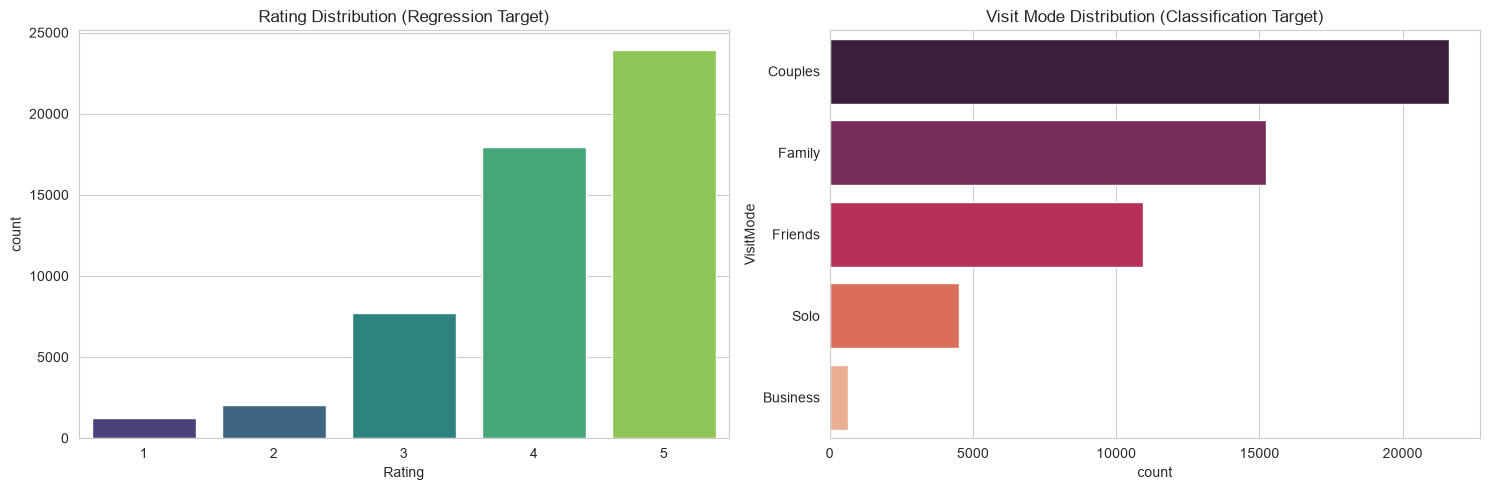

Rating %:
 Rating
1     2.4
2     3.8
3    14.6
4    33.9
5    45.2
Name: proportion, dtype: float64

VisitMode %:
 VisitMode
Couples     40.8
Family      28.7
Friends     20.7
Solo         8.5
Business     1.2
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='Rating', palette='viridis', ax=axes[0])
axes[0].set_title('Rating Distribution (Regression Target)')

order = df['VisitMode'].value_counts().index
sns.countplot(data=df, y='VisitMode', order=order, palette='rocket', ax=axes[1])
axes[1].set_title('Visit Mode Distribution (Classification Target)')

plt.tight_layout()
plt.show()

print("Rating %:\n", (df['Rating'].value_counts(normalize=True)*100).round(1).sort_index())
print("\nVisitMode %:\n", (df['VisitMode'].value_counts(normalize=True)*100).round(1))

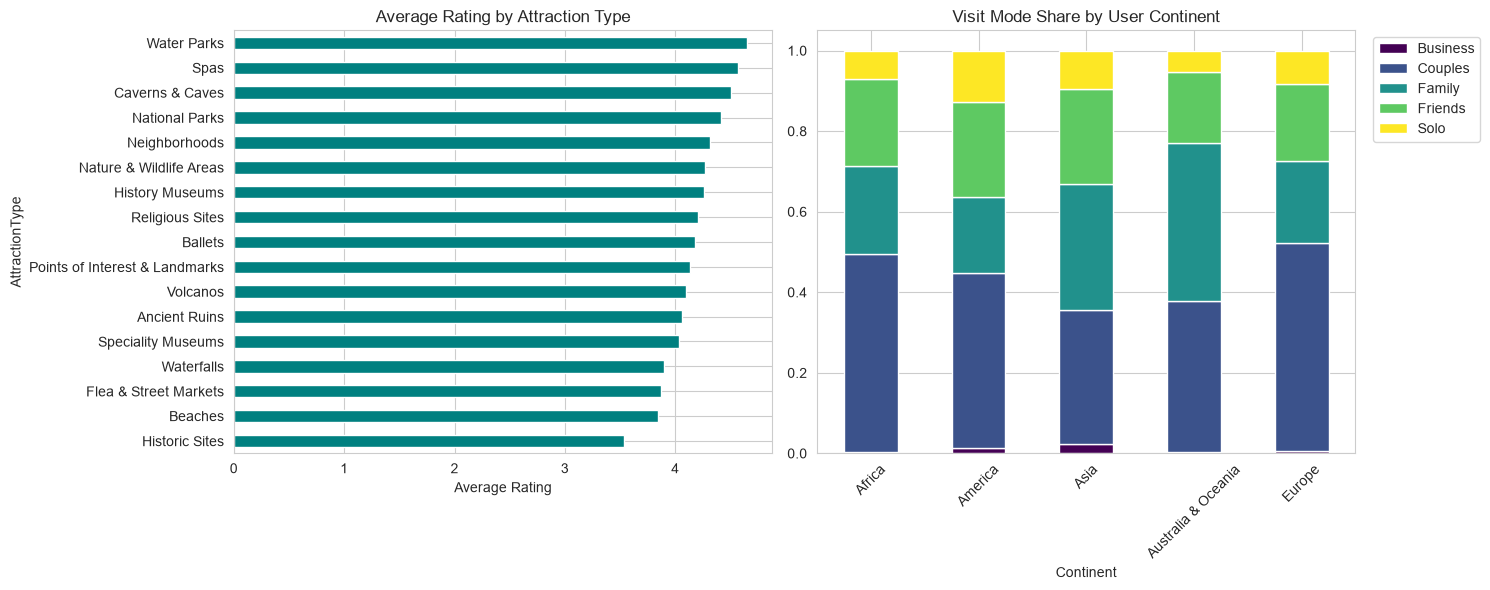

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

avg_rating_type = df.groupby('AttractionType')['Rating'].mean().sort_values()
avg_rating_type.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Average Rating by Attraction Type')
axes[0].set_xlabel('Average Rating')

visit_by_continent = pd.crosstab(df['Continent'], df['VisitMode'], normalize='index')
visit_by_continent.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Visit Mode Share by User Continent')
axes[1].legend(bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# User ka historical average rating (kya ye user generally high/low rate karta hai)
user_avg_rating = df.groupby('UserId')['Rating'].transform('mean')
df['user_avg_rating'] = user_avg_rating

# Attraction ka historical average rating (kya ye attraction generally accha/bura hai)
attraction_avg_rating = df.groupby('AttractionId')['Rating'].transform('mean')
df['attraction_avg_rating'] = attraction_avg_rating

# User ne kitni baar visit kiya hai total (experience proxy)
df['user_visit_count'] = df.groupby('UserId')['TransactionId'].transform('count')

print(df[['user_avg_rating', 'attraction_avg_rating', 'user_visit_count']].describe())

df.to_csv('tourism_cleaned_engineered.csv', index=False)
print("\nSaved:", df.shape)

       user_avg_rating  attraction_avg_rating  user_visit_count
count     52930.000000           52930.000000      52930.000000
mean          4.157699               4.157699          2.676781
std           0.828686               0.293003          3.463366
min           1.000000               3.415190          1.000000
25%           4.000000               3.976347          1.000000
50%           4.050000               4.219411          2.000000
75%           5.000000               4.267086          3.000000
max           5.000000               4.698795         59.000000

Saved: (52930, 24)


## EDA Summary

**Key findings:**
- Rating target is skewed positive (79% ratings are 4-5), while VisitMode target is imbalanced (Couples 40.8% vs Business only 1.2%)
- A critical data scoping finding: `Updated_Item.xlsx` lists 1,698 attractions, but Transaction data only covers 30 of them meaning collaborative filtering (rating-based) is   limited to those 30, while content-based filtering can extend to the full 1,698-attraction catalog
- AttractionType has only a narrow rating range (3.7-4.55), suggesting it's a weak standalone predictor for regression
- Business-mode visits are heavily concentrated among Asia-based users, a potentially useful signal for the classification task given how rare that class is

**Data quality issues found and handled:**
- 8 rows with unmatched City references after merging left as nulls (0.02% of data, not worth aggressive imputation)
- Several placeholder "-" values (Id = 0) in Region/Country/Continent tables, representing "unknown" excluded from group-based analysis where relevant

**Note for modeling notebooks:** `user_avg_rating` and `attraction_avg_rating` were computed here for exploration only. In the regression notebook, these must be recomputed **after** the train-test split, using only training data, to avoid target leakage.